In [1]:
import numpy as np
import tensorflow as tf
import random
import os

seed = 42

np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)
os.environ["PYTHONHASHSEED"] = str(seed)

In [2]:
#IMPORTS
#=========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import median_abs_deviation

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
roc_auc_score,
roc_curve,
classification_report,
confusion_matrix
)

from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
Dense,
Dropout,
BatchNormalization,
Input
)

from tensorflow.keras.callbacks import (
EarlyStopping,
ReduceLROnPlateau,
ModelCheckpoint
)

from tensorflow.keras.regularizers import l2

In [4]:
#PATHS
#=========================================================

BASE_DL = r"C:\Users\food1\Downloads\NCC 2024\Course 2025\AI\Python\DL"

PATHS = {

"cgga693_clin":
    BASE_DL + r"\CGGA.mRNAseq_693_clinical.20200506.txt\CGGA.mRNAseq_693_clinical.20200506.txt",

"cgga325_clin":
    BASE_DL + r"\CGGA.mRNAseq_325_clinical.20200506.txt\CGGA.mRNAseq_325_clinical.20200506.txt",

"cgga693_expr":
    BASE_DL + r"\CGGA.mRNAseq_693.Read_Counts-genes.20220620.txt\CGGA.mRNAseq_693.Read_Counts-genes.20220620.txt",

"cgga325_expr":
    BASE_DL + r"\CGGA.mRNAseq_325.Read_Counts-genes.20220620.txt\CGGA.mRNAseq_325.Read_Counts-genes.20220620.txt",

}


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier


import importlib

import torch 
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import CyclicLR
from torch.utils.data import Dataset, DataLoader, RandomSampler

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
from matplotlib.cbook import boxplot_stats
from matplotlib.ticker import PercentFormatter
from matplotlib.font_manager import FontProperties
import shap

from base_utils import get_new_cols, check_filename, drop_useless_cols, load_data, write_file
from preprocessing_utils import remove_rarely_mutated_genes, log1p_mutations, remove_nearly_constant, apply_scaler, COMBAT, CorrelationAnalysis, ExpressionStabilitySelector
BASE_DL = r"C:\Users\food1\Downloads\NCC 2024\Course 2025\AI\Python\DL"

paths = {
    'gbm': {'cbio': {'firehose': 'data/tcga/gbm/cbio_firehose/', 'pancan': 'data/tcga/gbm/cbio_pancan/'}, 'xena': 'data/tcga/gbm/xena/'},
    'lgg': {'cbio': {'firehose': 'data/tcga/lgg/cbio_firehose/', 'pancan': 'data/tcga/lgg/cbio_pancan/'}, 'xena': 'data/tcga/lgg/xena/'},
    'gbmlgg': {'cbio': 'data/tcga/gbmlgg/cbio/', 'xena': 'data/tcga/gbmlgg/xena/'},
    'gdc': 'data/tcga/gdc/',
    'glass': 'data/glass/'
}

In [10]:
# =========================================================
# FILE LOADER
# =========================================================

def load_txt(path, **kwargs):

    for sep in ["\t", ","]:

        try:

            df = pd.read_csv(
                path,
                sep=sep,
                comment="#",
                **kwargs
            )

            if df.shape[1] > 1:
                return df

        except:
            pass

    raise ValueError(f"Cannot parse file: {path}")
#=========================================================
#LOAD DATA
#=========================================================

cgga693_clin = load_txt(PATHS["cgga693_clin"])

cgga325_clin = load_txt(PATHS["cgga325_clin"])

cgga693_expr = load_txt(
PATHS["cgga693_expr"],
index_col=0
)

cgga325_expr = load_txt(
PATHS["cgga325_expr"],
index_col=0
)

tcga_clin = pd.read_csv(
    r"C:\Users\food1\Downloads\NCC 2024\Course 2025\AI\Python\DL\tcga_clin_ready.csv"
)
tcga_expr = pd.read_csv(
    "data/tcga_tcga_gbmlgg_expr.csv",
    index_col=0,
    compression="gzip"
)

In [11]:
#CLEAN TCGA IDs
#=========================================================

def clean_tcga_id(x):

    if pd.isna(x):
        return np.nan

    x = str(x).strip()

    x = x[:12]

    return x

In [18]:
# TMZ COLUMN
#=========================================================

def detect_tmz_col(clin_df):

    keywords = [
        "tmz",
        "temozolomide",
        "chemo",
        "chemotherapy",
        "treatment"
    ]

    for col in clin_df.columns:

        col_lower = col.lower()

        if any(k in col_lower for k in keywords):
            return col

    raise ValueError("TMZ column not found")

In [19]:
# =========================================================
# PREPROCESS CGGA
# =========================================================

def preprocess_cgga(expr_df, clin_df, batch_name):

    clin = clin_df.copy()

    # -----------------------------------------------------
    # Detect sample ID column
    # -----------------------------------------------------
    id_col = next(
        (
            c for c in clin.columns
            if "id" in c.lower()
        ),
        clin.columns[0]
    )

    tmz_col = detect_tmz_col(clin)

    # -----------------------------------------------------
    # TMZ labels
    # -----------------------------------------------------
    vals = clin[tmz_col].astype(str).str.lower()

    clin["TMZ_label"] = np.nan

    clin.loc[
        vals.str.contains(
            "tmz|treated|yes|1",
            na=False
        ),
        "TMZ_label"
    ] = 1

    clin.loc[
        vals.str.contains(
            "untreated|control|no|0",
            na=False
        ),
        "TMZ_label"
    ] = 0

    clin = clin[
        clin["TMZ_label"].notna()
    ].copy()

    clin["TMZ_label"] = (
        clin["TMZ_label"]
        .astype(int)
    )

    # -----------------------------------------------------
    # Align samples
    # -----------------------------------------------------
    sample_ids = (
        clin[id_col]
        .astype(str)
    )

    sample_ids = sample_ids[
        sample_ids.isin(expr_df.columns)
    ]

    expr_sub = expr_df.loc[:, sample_ids]

    clin_sub = (
        clin
        .set_index(id_col)
        .loc[sample_ids]
        .reset_index()
    )

    clin_sub["sample_id"] = sample_ids.values
    clin_sub["batch"] = batch_name

    return expr_sub, clin_sub

In [25]:
# =========================================================
# PREPROCESS TCGA
# =========================================================

def preprocess_tcga(expr_df, clin_df):

    clin = clin_df.copy()

    # correct ID column
    id_col = "SAMPLE_ID"

    clin[id_col] = clin[id_col].apply(clean_tcga_id)

    clin = clin.dropna(subset=[id_col])
    clin = clin.drop_duplicates(subset=[id_col])

    sample_ids = [s for s in clin[id_col] if s in expr_df.columns]

    expr_sub = expr_df.loc[:, sample_ids]

    clin_sub = clin.set_index(id_col).loc[sample_ids].reset_index()

    clin_sub["sample_id"] = sample_ids

    return expr_sub, clin_sub

In [26]:
# =========================================================
# RUN PREPROCESSING
# =========================================================

# ---------------------------
# CGGA 693
# ---------------------------
cgga693_e, cgga693_c = preprocess_cgga(
    cgga693_expr,
    cgga693_clin,
    "CGGA693"
)

# ---------------------------
# CGGA 325
# ---------------------------
cgga325_e, cgga325_c = preprocess_cgga(
    cgga325_expr,
    cgga325_clin,
    "CGGA325"
)

In [28]:
# common genes between CGGA datasets
common_genes = sorted(
    cgga693_e.index.intersection(cgga325_e.index)
)

cgga693_e = cgga693_e.loc[common_genes]
cgga325_e = cgga325_e.loc[common_genes]

# merge expression (samples)
cgga_expr = pd.concat(
    [cgga693_e, cgga325_e],
    axis=1
)

# add batch info (VERY IMPORTANT)
cgga693_c["batch"] = "CGGA693"
cgga325_c["batch"] = "CGGA325"

cgga_clin = pd.concat(
    [cgga693_c, cgga325_c],
    axis=0,
    ignore_index=True
)

# TCGA preprocessing
tcga_expr, tcga_clin = preprocess_tcga(tcga_expr, tcga_clin)

# align gene space across ALL datasets
common_genes = sorted(
    cgga_expr.index.intersection(tcga_expr.index)
)

cgga_expr = cgga_expr.loc[common_genes]
tcga_expr = tcga_expr.loc[common_genes]

In [29]:
# =========================================================
# CLEAN EXPRESSION VALUES
# =========================================================

cgga_expr = cgga_expr.apply(pd.to_numeric, errors="coerce")
tcga_expr = tcga_expr.apply(pd.to_numeric, errors="coerce")

# replace infinities with NaN
cgga_expr = cgga_expr.replace([np.inf, -np.inf], np.nan)
tcga_expr = tcga_expr.replace([np.inf, -np.inf], np.nan)

# fill missing values
cgga_expr = cgga_expr.fillna(0)
tcga_expr = tcga_expr.fillna(0)

# =========================================================
# REMOVE NEGATIVE VALUES
# =========================================================

cgga_expr[cgga_expr < 0] = 0
tcga_expr[tcga_expr < 0] = 0

# =========================================================
# LOG2 NORMALIZATION
# =========================================================

cgga_expr = np.log2(cgga_expr + 1)
tcga_expr = np.log2(tcga_expr + 1)

In [30]:
# =========================================================
# REMOVE NON-CODING / LOW-QUALITY GENES
# =========================================================

bad_patterns = (
    "RP11-",
    "RP5-",
    "RP1-",
    "LINC",
    "MIR",
    "SNORD",
    "AC",
    "AL",
    "AP"
)

good_genes = []

for g in cgga_expr.index:

    g = str(g)

    # Remove unwanted gene patterns
    if any(p in g for p in bad_patterns):
        continue

    # Remove invalid gene names
    if g.startswith("."):
        continue

    if len(g) < 2:
        continue

    good_genes.append(g)

# =========================================================
# Keep filtered genes
# =========================================================

cgga_expr = cgga_expr.loc[good_genes]
tcga_expr = tcga_expr.loc[good_genes]

In [31]:
# =========================================================
# BUILD BIOLOGICAL TMZ RESISTANCE LABELS
# =========================================================

df = cgga_clin.copy()

tmz_col = "Chemo_status (TMZ treated=1;un-treated=0)"
mgmt_col = "MGMTp_methylation_status"
os_col = "OS"

# ---------------------------------------------------------
# Clean metadata columns
# ---------------------------------------------------------

df[tmz_col] = (
    df[tmz_col]
    .astype(str)
    .str.lower()
)

df[mgmt_col] = (
    df[mgmt_col]
    .astype(str)
    .str.lower()
)

df[os_col] = pd.to_numeric(
    df[os_col],
    errors="coerce"
)

# =========================================================
# TMZ RESISTANCE SIGNATURE
# =========================================================

TR_marker = [
    "PAPPA",
    "ANXA3",
    "LRRC3",
    "EGR4"
]

available_genes = [
    g for g in TR_marker
    if g in cgga_expr.index
]

print("Available TR genes:", available_genes)

# ---------------------------------------------------------
# Compute resistance score
# ---------------------------------------------------------

TR_score = (
    cgga_expr
    .loc[available_genes]
    .mean(axis=0)
)

df["TR_score"] = (
    df["sample_id"]
    .map(TR_score)
)

df["TR_score"] = (
    df["TR_score"]
    .fillna(df["TR_score"].median())
)

# =========================================================
# MEDIAN SPLITS
# =========================================================

os_median = df[os_col].median()
tr_median = df["TR_score"].median()

# =========================================================
# BASIC FEATURES
# =========================================================

tmz_treated = df[tmz_col].str.contains(
    "1|yes|tmz|treated",
    na=False
)

mgmt_methyl = df[mgmt_col].str.contains(
    "methylated",
    na=False
)

# =========================================================
# RESISTANCE SCORE
# =========================================================

resistance_score = (

    (~mgmt_methyl).astype(int) +

    (df[os_col] < os_median).astype(int) +

    (df["TR_score"] >= tr_median).astype(int)

)

# =========================================================
# FINAL LABELS
#
# 0 = Sensitive
# 1 = Resistant
# =========================================================

df["TMZ_response"] = np.nan

df.loc[
    resistance_score <= 1,
    "TMZ_response"
] = 0

df.loc[
    resistance_score >= 2,
    "TMZ_response"
] = 1

# =========================================================
# KEEP TMZ-TREATED ONLY
# =========================================================

df = df[
    tmz_treated
].copy()

df = df[
    df["TMZ_response"].notna()
].copy()

df["TMZ_response"] = (
    df["TMZ_response"]
    .astype(int)
)

# =========================================================
# LABEL SUMMARY
# =========================================================

print("\nTMZ LABEL SUMMARY")
print(df["TMZ_response"].value_counts())

Available TR genes: ['ANXA3', 'LRRC3', 'EGR4']

TMZ LABEL SUMMARY
TMZ_response
0    469
1    210
Name: count, dtype: int64


In [32]:
# MAD FEATURE SELECTION

# =========================================================

gene_mad = pd.Series(
    [
        median_abs_deviation(
            cgga_expr.loc[g]
        )
        for g in cgga_expr.index
    ],
    index=cgga_expr.index
)

top_genes = (
gene_mad
.nlargest(3000)
.index
)

cgga_expr = cgga_expr.loc[top_genes]

tcga_expr = tcga_expr.loc[top_genes]

# =========================================================

# BUILD MATRICES

# =========================================================

X = cgga_expr.T.copy()

y = (
df
.set_index("sample_id")
.reindex(X.index)["TMZ_response"]
)

# remove missing labels safely
valid_samples = y.dropna().index

X = X.loc[valid_samples]
y = y.loc[valid_samples].astype(int)

# keep only matched samples
common_samples = (
X.index
.intersection(y.index)
)

X = X.loc[common_samples]
y = y.loc[common_samples]

X_test = tcga_expr.T.copy()

In [33]:
# TRAIN / VALIDATION SPLIT

# =========================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# =========================================================
# STANDARDIZATION
# =========================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# =========================================================
# CLASS WEIGHTS
# =========================================================

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight = dict(
    zip(np.unique(y_train), weights)
)

print(class_weight)

{np.int64(0): np.float64(0.724), np.int64(1): np.float64(1.6160714285714286)}


In [34]:
# BUILD MLP

# =========================================================

def build_mlp(input_dim):

    model = Sequential([

        Input(shape=(input_dim,)),

        Dense(
            256,
            kernel_regularizer=l2(1e-4)
        ),

        BatchNormalization(),

        tf.keras.layers.Activation("relu"),

        Dropout(0.3),

        Dense(
            128,
            kernel_regularizer=l2(1e-4)
        ),

        BatchNormalization(),

        tf.keras.layers.Activation("relu"),

        Dropout(0.3),

        Dense(
            64,
            kernel_regularizer=l2(1e-4)
        ),

        BatchNormalization(),

        tf.keras.layers.Activation("relu"),

        Dropout(0.2),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(

        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-3
        ),

        loss="binary_crossentropy",

        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc")
        ]
    )

    return model

In [35]:
# MODEL

# =========================================================

model = build_mlp(
    X_train.shape[1]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │         768,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 811,265 (3.09 MB)

 Trainable params: 810,369 (3.09 MB)

 Non-trainable params: 896 (3.50 KB)

In [36]:
# CALLBACKS
# =========================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, roc_curve
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
early_stop = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=20,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_auc",
    mode="max",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

# =========================================================
# K-FOLD TRAINING
# =========================================================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_aucs = []
train_losses = []
val_losses = []

best_model = None
best_auc = 0

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    print(f"\n================ Fold {fold+1} ================\n")

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # build model per fold
    model = build_mlp(X_train.shape[1])

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=200,
        batch_size=16,
        class_weight=class_weight,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )

    # store loss curves
    train_losses.append(history.history["loss"])
    val_losses.append(history.history["val_loss"])

    # validation AUC
    val_probs = model.predict(X_val).ravel()
    auc = roc_auc_score(y_val, val_probs)

    print("Fold AUC:", auc)
    fold_aucs.append(auc)

    # keep best model
    if auc > best_auc:
        best_auc = auc
        best_model = model

# =========================================================
# FINAL RESULTS
# =========================================================

print("\n================ FINAL K-FOLD RESULTS ================")
print("Mean AUC:", np.mean(fold_aucs))
print("Std AUC:", np.std(fold_aucs))

model = best_model


================ Fold 1 ================

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Fold AUC: 0.7629179331306991

================ Fold 2 ================

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Fold AUC: 0.839918946301925

================ Fold 3 ================

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000224624BC680> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/f

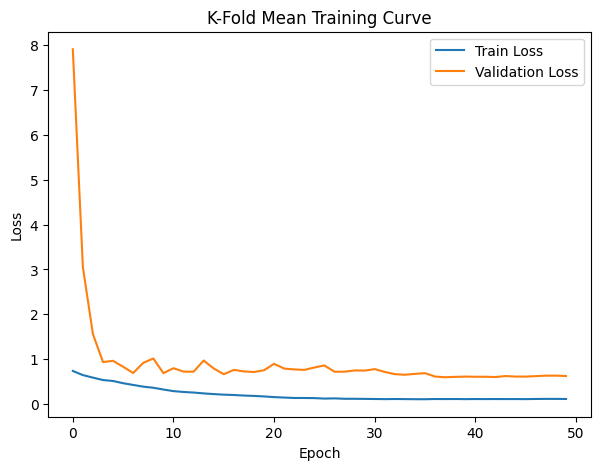

In [37]:
# LOSS CURVE VISUALIZATION (K-FOLD MEAN)
# =========================================================

max_epochs = max(len(x) for x in train_losses)

train_matrix = np.array([
    np.pad(x, (0, max_epochs - len(x)), constant_values=np.nan)
    for x in train_losses
])

val_matrix = np.array([
    np.pad(x, (0, max_epochs - len(x)), constant_values=np.nan)
    for x in val_losses
])

mean_train_loss = np.nanmean(train_matrix, axis=0)
mean_val_loss = np.nanmean(val_matrix, axis=0)

plt.figure(figsize=(7,5))

plt.plot(mean_train_loss, label="Train Loss")
plt.plot(mean_val_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("K-Fold Mean Training Curve")
plt.legend()
plt.savefig(
    "Training_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

Final Validation AUC: 0.9989759344598055
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        93
           1       0.93      1.00      0.97        42

    accuracy                           0.98       135
   macro avg       0.97      0.98      0.97       135
weighted avg       0.98      0.98      0.98       135



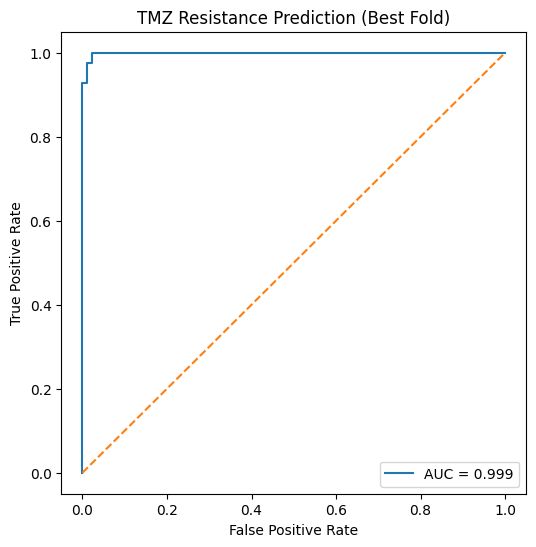

In [38]:
# FINAL VALIDATION (using best model)
# =========================================================

val_probs = model.predict(X_val).ravel()
val_pred = (val_probs > 0.5).astype(int)

auc = roc_auc_score(y_val, val_probs)

print("\nFinal Validation AUC:", auc)
print(classification_report(y_val, val_pred))

# =========================================================
# ROC CURVE
# =========================================================

fpr, tpr, _ = roc_curve(y_val, val_probs)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("TMZ Resistance Prediction (Best Fold)")
plt.legend()
plt.show()

In [39]:
# =========================================================
# TRAINING PERFORMANCE
# =========================================================

train_probs = model.predict(X_train).ravel()
train_pred = (train_probs > 0.5).astype(int)

train_auc = roc_auc_score(y_train, train_probs)

print("\n================ TRAIN PERFORMANCE ================")
print("Train AUC:", train_auc)
print(classification_report(y_train, train_pred))


# =========================================================
# VALIDATION PERFORMANCE
# =========================================================

val_probs = model.predict(X_val).ravel()
val_pred = (val_probs > 0.5).astype(int)

val_auc = roc_auc_score(y_val, val_probs)

print("\n================ VALIDATION PERFORMANCE ================")
print("Validation AUC:", val_auc)
print(classification_report(y_val, val_pred))

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

================ TRAIN PERFORMANCE ================
Train AUC: 0.979720744680851
              precision    recall  f1-score   support

           0       0.97      0.94      0.95       376
           1       0.87      0.93      0.90       168

    accuracy                           0.94       544
   macro avg       0.92      0.94      0.93       544
weighted avg       0.94      0.94      0.94       544

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

================ VALIDATION PERFORMANCE ================
Validation AUC: 0.9989759344598055
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        93
           1       0.93      1.00      0.97        42

    accuracy                           0.98       135
   macro avg       0.97      0.98      0.97       135
weighted avg       0.98      0.98      0.98       135



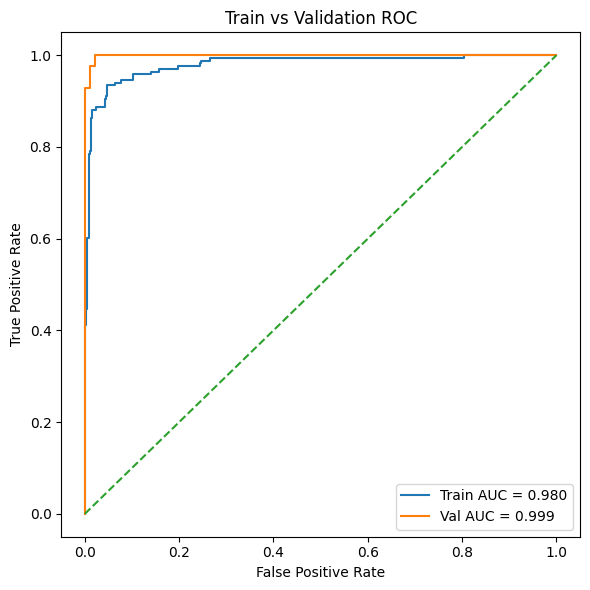

In [40]:
fpr_tr, tpr_tr, _ = roc_curve(y_train, train_probs)
fpr_val, tpr_val, _ = roc_curve(y_val, val_probs)

# =========================================================
# CREATE FIGURE
# =========================================================

fig, ax = plt.subplots(figsize=(6,6))

# TRAIN ROC
ax.plot(
    fpr_tr,
    tpr_tr,
    label=f"Train AUC = {train_auc:.3f}"
)

# VALIDATION ROC
ax.plot(
    fpr_val,
    tpr_val,
    label=f"Val AUC = {val_auc:.3f}"
)

# RANDOM LINE
ax.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

# LABELS
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

ax.set_title("Train vs Validation ROC")

ax.legend()

plt.tight_layout()

# =========================================================
# SAVE FIRST
# =========================================================

fig.savefig(
    "ROC_curve.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

# =========================================================
# SHOW AFTER SAVING
# =========================================================

plt.show()

In [75]:
# TCGA PREDICTION
# =========================================================

tcga_probs = model.predict(X_test_scaled).ravel()

tcga_df = pd.DataFrame({
    "Sample": X_test.index,
    "Resistance_Probability": tcga_probs
})

def risk_group(p):
    if p > 0.75:
        return "High Resistant"
    elif p > 0.5:
        return "Resistant"
    elif p > 0.25:
        return "Sensitive"
    else:
        return "High Sensitive"

tcga_df["Risk_Group"] = tcga_df["Resistance_Probability"].apply(risk_group)

print(tcga_df.head())

tcga_df.to_csv("TCGA_MLP_predictions.csv", index=False)

print("\nSaved: TCGA_MLP_predictions.csv")

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
         Sample  Resistance_Probability      Risk_Group
0  TCGA-CS-4938                0.000001  High Sensitive
1  TCGA-CS-4941                0.000002  High Sensitive
2  TCGA-CS-4942                0.000002  High Sensitive
3  TCGA-CS-4943                0.000002  High Sensitive
4  TCGA-CS-4944                0.000002  High Sensitive

Saved: TCGA_MLP_predictions.csv


In [76]:
print(y.value_counts(normalize=True))

TMZ_response
0    0.690722
1    0.309278
Name: proportion, dtype: float64


In [77]:
train_probs = model.predict(X_train).ravel()

print(train_probs.min(), train_probs.max())
print(train_probs.mean())

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
0.00011255091 0.9999687
0.34976268


In [78]:
print(X_train.mean().mean())
print(X_test_scaled.mean().mean())

6.02869464570231
-2.637473144661153


In [79]:
# =========================================================
# DEFINE RESISTANCE USING PERCENTILES
# =========================================================

q75 = tcga_df["Resistance_Probability"].quantile(0.75)
q50 = tcga_df["Resistance_Probability"].quantile(0.50)
q25 = tcga_df["Resistance_Probability"].quantile(0.25)

def risk_group(p):

    if p >= q75:
        return "High Resistant"

    elif p >= q50:
        return "Resistant"

    elif p >= q25:
        return "Sensitive"

    else:
        return "High Sensitive"

tcga_df["Risk_Group"] = (
    tcga_df["Resistance_Probability"]
    .apply(risk_group)
)

In [80]:
# top 20% = resistant
threshold = tcga_df["Resistance_Probability"].quantile(0.80)

tcga_df["Predicted_Resistance"] = (
    tcga_df["Resistance_Probability"] >= threshold
).astype(int)

In [81]:
tcga_df["Predicted_Resistance"].value_counts()

Predicted_Resistance
0    533
1    134
Name: count, dtype: int64

In [82]:
resistant_tcga = tcga_df[
    tcga_df["Predicted_Resistance"] == 1
]

resistant_tcga.to_csv(
    "TCGA_predicted_resistant.csv",
    index=False
)

In [83]:
# =========================================================
# CLEAN TCGA IDS
# =========================================================

tcga_df["Sample"] = tcga_df["Sample"].str[:12]
tcga_clin["SAMPLE_ID"] = tcga_clin["SAMPLE_ID"].str[:12]

# =========================================================
# MERGE
# =========================================================

surv_df = tcga_df.merge(
    tcga_clin,
    left_on="Sample",
    right_on="SAMPLE_ID",
    how="inner"
)

print(surv_df.shape)
surv_df.head()

(667, 61)


,Sample,Resistance_Probability,Risk_Group,Predicted_Resistance,SAMPLE_ID,PATIENT_ID,TISSUE_SOURCE_SITE,WHOLE_EXOME_SEQUENCING,WHOLE_GENOME_SEQUENCING,RNASEQ_DATA,...,TMB_NONSYNONYMOUS,STUDY,BCR_STATUS,HISTOLOGICAL_DIAGNOSIS,AGE,SEX,OS_MONTHS,OS_STATUS,KARNOFSKY_PERFORMANCE_SCORE,sample_id
0,TCGA-CS-4938,0.000001,High Sensitive,0,TCGA-CS-4938,TCGA-CS-4938,Thomas Jefferson University,Yes,Yes,Yes,...,0.366667,Brain Lower Grade Glioma,IGC,astrocytoma,31.0,Female,4.7,0:LIVING,90.0,TCGA-CS-4938
1,TCGA-CS-4941,0.000002,Resistant,0,TCGA-CS-4941,TCGA-CS-4941,Thomas Jefferson University,Yes,Yes,Yes,...,1.400000,Brain Lower Grade Glioma,IGC,astrocytoma,67.0,Male,7.7,1:DECEASED,90.0,TCGA-CS-4941
2,TCGA-CS-4942,0.000002,Sensitive,0,TCGA-CS-4942,TCGA-CS-4942,Thomas Jefferson University,Yes,No,Yes,...,0.600000,Brain Lower Grade Glioma,IGC,astrocytoma,44.0,Female,43.9,1:DECEASED,90.0,TCGA-CS-4942
3,TCGA-CS-4943,0.000002,Resistant,0,TCGA-CS-4943,TCGA-CS-4943,Thomas Jefferson University,Yes,No,Yes,...,0.700000,Brain Lower Grade Glioma,IGC,astrocytoma,37.0,Male,18.1,0:LIVING,50.0,TCGA-CS-4943
4,TCGA-CS-4944,0.000002,Sensitive,0,TCGA-CS-4944,TCGA-CS-4944,Thomas Jefferson University,Yes,Yes,Yes,...,0.566667,Brain Lower Grade Glioma,IGC,astrocytoma,50.0,Male,10.6,0:LIVING,90.0,TCGA-CS-4944


In [84]:
print(tcga_df["Resistance_Probability"].describe())
print(tcga_df["Predicted_Resistance"].value_counts())

count    6.670000e+02
mean     1.944642e-06
std      5.778640e-07
min      8.222081e-07
25%      1.504452e-06
50%      1.819683e-06
75%      2.308007e-06
max      4.077643e-06
Name: Resistance_Probability, dtype: float64
Predicted_Resistance
0    533
1    134
Name: count, dtype: int64


In [86]:
# =========================================================
# CLEAN IDS
# =========================================================

tcga_df["Sample"] = tcga_df["Sample"].str[:12]

tcga_clin["SAMPLE_ID"] = (
    tcga_clin["SAMPLE_ID"]
    .astype(str)
    .str[:12]
)

# =========================================================
# MERGE
# =========================================================

surv_df = tcga_df.merge(
    tcga_clin,
    left_on="Sample",
    right_on="SAMPLE_ID",
    how="inner"
)

print(surv_df.shape)

(667, 61)


In [89]:
# =========================================================
# SURVIVAL TIME
# =========================================================

surv_df["OS"] = pd.to_numeric(
    surv_df["OS_MONTHS"],
    errors="coerce"
)

# =========================================================
# SURVIVAL EVENT
# =========================================================

surv_df["OS_event"] = (
    surv_df["OS_STATUS"]
    .astype(str)
    .str.lower()
    .str.contains("deceased|dead|1")
).astype(int)

# =========================================================
# REMOVE MISSING
# =========================================================

surv_df = surv_df.dropna(
    subset=["OS"]
)

print(surv_df[["OS", "OS_event"]].head())

     OS  OS_event
0   4.7         0
1   7.7         1
2  43.9         1
3  18.1         0
4  10.6         0


In [88]:
print(surv_df.columns.tolist())

['Sample', 'Resistance_Probability', 'Risk_Group', 'Predicted_Resistance', 'SAMPLE_ID', 'PATIENT_ID', 'TISSUE_SOURCE_SITE', 'WHOLE_EXOME_SEQUENCING', 'WHOLE_GENOME_SEQUENCING', 'RNASEQ_DATA', 'SNP6', 'U133A', 'HM450', 'HM27', 'RPPA', 'GRADE', 'PERCENT_ANEUPLOIDY', 'IDH_1P19Q_SUBTYPE', 'PURITY_ABSOLUTE', 'ABSOLUTE_EXTRACT_PLOIDY', 'RPPA_CLUSTER', 'IDH_STATUS', 'IDH_CODEL_SUBTYPE', 'MGMT_PROMOTER_STATUS', 'CHR_7_GAIN_CHR_10_LOSS', 'CHR_19_20_CO_GAIN', 'TERT_PROMOTER_STATUS', 'TERT_EXPRESSION_LOG2', 'TERT_EXPRESSION_STATUS', 'ATRX_STATUS', 'DAXX_STATUS', 'TELOMERE_MAINTENANCE', 'BRAF_V600E_STATUS', 'BRAF_KIAA1549_FUSION', 'ESTIMATE_STROMAL_SCORE', 'ESTIMATE_IMMUNE_SCORE', 'ESTIMATE_COMBINED_SCORE', 'ORIGINAL_SUBTYPE', 'TRANSCRIPTOME_SUBTYPE', 'PAN_GLIOMA_RNA_EXPRESSION_CLUSTER', 'IDH_SPECIFIC_RNA_EXPRESSION_CLUSTER', 'PAN_GLIOMA_DNA_METHYLATION_CLUSTER', 'IDH_SPECIFIC_DNA_METHYLATION_CLUSTER', 'SUPERVISED_DNA_METHYLATION_CLUSTER', 'RANDOM_FOREST_STURM_CLUSTER', 'TELOMERE_LENGTH_ESTIMATE_I

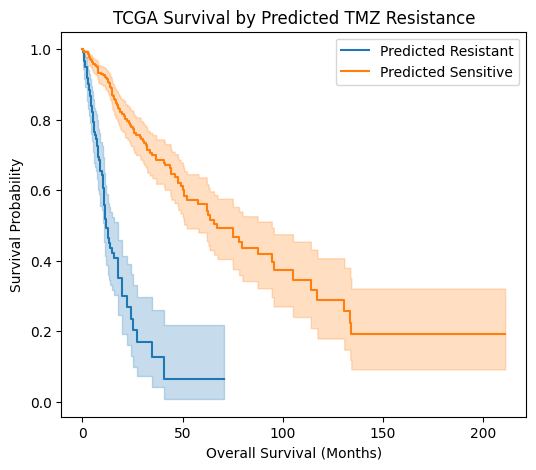

In [90]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt

# =========================================================
# GROUPS
# =========================================================

resistant = surv_df[
    surv_df["Predicted_Resistance"] == 1
]

sensitive = surv_df[
    surv_df["Predicted_Resistance"] == 0
]

# remove missing survival values (IMPORTANT)
resistant = resistant.dropna(subset=["OS", "OS_event"])
sensitive = sensitive.dropna(subset=["OS", "OS_event"])

# =========================================================
# KM CURVE
# =========================================================

kmf = KaplanMeierFitter()

plt.figure(figsize=(6,5))

# Resistant
if len(resistant) > 0:
    kmf.fit(
        resistant["OS"],
        resistant["OS_event"],
        label="Predicted Resistant"
    )
    kmf.plot_survival_function()

# Sensitive
if len(sensitive) > 0:
    kmf.fit(
        sensitive["OS"],
        sensitive["OS_event"],
        label="Predicted Sensitive"
    )
    kmf.plot_survival_function()

plt.xlabel("Overall Survival (Months)")
plt.ylabel("Survival Probability")
plt.title("TCGA Survival by Predicted TMZ Resistance")

plt.show()

In [91]:
result = logrank_test(
    resistant["OS"],
    sensitive["OS"],
    event_observed_A=resistant["OS_event"],
    event_observed_B=sensitive["OS_event"]
)

print(result.summary)

   test_statistic             p   -log2(p)
0      132.658195  1.073984e-30  99.554871


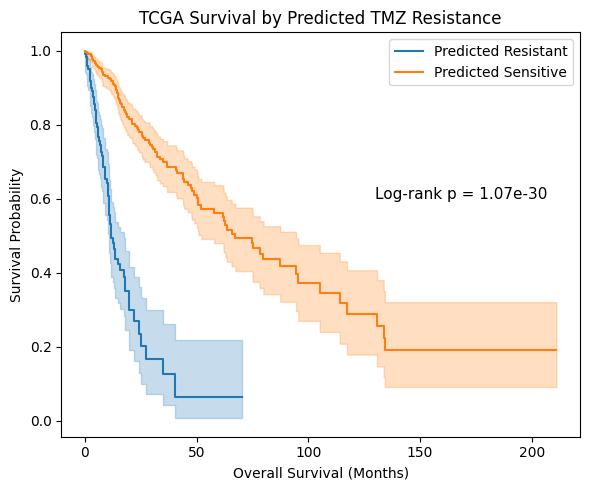

In [96]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt

# =========================================================
# GROUPS
# =========================================================

resistant = surv_df[surv_df["Predicted_Resistance"] == 1].dropna(subset=["OS", "OS_event"])
sensitive = surv_df[surv_df["Predicted_Resistance"] == 0].dropna(subset=["OS", "OS_event"])

# =========================================================
# LOG-RANK TEST
# =========================================================

result = logrank_test(
    resistant["OS"],
    sensitive["OS"],
    event_observed_A=resistant["OS_event"],
    event_observed_B=sensitive["OS_event"]
)

p_value = result.p_value

# =========================================================
# KM CURVE
# =========================================================

kmf = KaplanMeierFitter()

plt.figure(figsize=(6,5))

# Resistant
kmf.fit(
    resistant["OS"],
    event_observed=resistant["OS_event"],
    label="Predicted Resistant"
)

ax = kmf.plot_survival_function()

# Sensitive
kmf.fit(
    sensitive["OS"],
    event_observed=sensitive["OS_event"],
    label="Predicted Sensitive"
)

kmf.plot_survival_function(ax=ax)

# =========================================================
# ADD P-VALUE TO FIGURE
# =========================================================

# safer dynamic placement (instead of fixed x=130)
x_pos = surv_df["OS"].max() * 0.6
y_pos = 0.2

plt.text(
    x=130,
    y=0.6,
    s=f"Log-rank p = {p_value:.2e}",
    fontsize=11
)

# =========================================================
# LABELS
# =========================================================

plt.xlabel("Overall Survival (Months)")
plt.ylabel("Survival Probability")
plt.title("TCGA Survival by Predicted TMZ Resistance")

plt.legend()
plt.tight_layout()

plt.savefig(
    "KM_survival_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

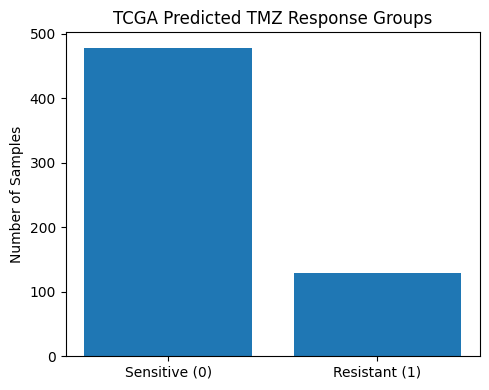

In [97]:
import matplotlib.pyplot as plt

counts = surv_df["Predicted_Resistance"].value_counts().sort_index()

plt.figure(figsize=(5,4))
plt.bar(["Sensitive (0)", "Resistant (1)"], counts.values)

plt.ylabel("Number of Samples")
plt.title("TCGA Predicted TMZ Response Groups")

plt.tight_layout()
plt.show()

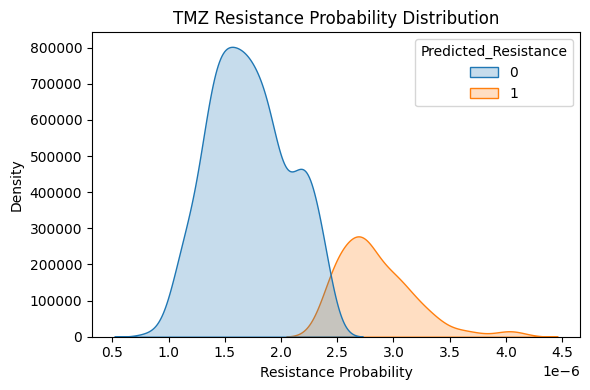

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.kdeplot(
    data=surv_df,
    x="Resistance_Probability",
    hue="Predicted_Resistance",
    fill=True
)

plt.title("TMZ Resistance Probability Distribution")
plt.xlabel("Resistance Probability")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

In [101]:
from scipy.stats import ttest_ind
import numpy as np
import pandas as pd

In [103]:
# expression: genes x samples
expr = tcga_expr.copy()

# labels dataframe must contain sample IDs
labels = tcga_df.set_index("Sample")["Predicted_Resistance"]

In [104]:
common_samples = expr.columns.intersection(labels.index)

expr = expr[common_samples]
labels = labels.loc[common_samples]

In [105]:
resistant_samples = labels[labels == 1].index
sensitive_samples = labels[labels == 0].index

In [106]:
resistant_expr = expr[resistant_samples]
sensitive_expr = expr[sensitive_samples]

In [107]:
genes = expr.index

logFC = []
pvals = []

for g in genes:
    r = resistant_expr.loc[g]
    s = sensitive_expr.loc[g]

    # log fold change
    fc = np.log2(r.mean() + 1e-9) - np.log2(s.mean() + 1e-9)

    # t-test
    stat, p = ttest_ind(r, s, equal_var=False)

    logFC.append(fc)
    pvals.append(p)

In [108]:
volcano = pd.DataFrame({
    "gene": genes,
    "logFC": logFC,
    "pval": pvals
})

volcano["-log10(p)"] = -np.log10(volcano["pval"] + 1e-300)

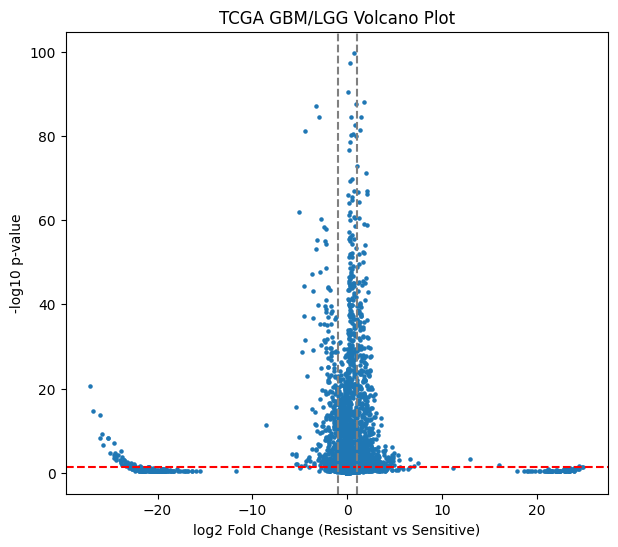

In [109]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

plt.scatter(
    volcano["logFC"],
    volcano["-log10(p)"],
    s=5
)

# threshold lines
plt.axhline(-np.log10(0.05), color="red", linestyle="--")
plt.axvline(1, color="grey", linestyle="--")
plt.axvline(-1, color="grey", linestyle="--")

plt.xlabel("log2 Fold Change (Resistant vs Sensitive)")
plt.ylabel("-log10 p-value")
plt.title("TCGA GBM/LGG Volcano Plot")

plt.show()

In [110]:
import numpy as np

volcano["adj_p"] = np.minimum(volcano["pval"] * len(volcano), 1.0)  # simple Bonferroni

In [111]:
sig_genes = volcano[
    (volcano["adj_p"] < 0.05) &
    (np.abs(volcano["logFC"]) > 1)
].copy()

In [112]:
sig_genes = sig_genes.sort_values(
    by=["adj_p", "logFC"],
    ascending=[True, False]
)

In [113]:
sig_genes.to_csv("TCGA_DE_genes_resistant_vs_sensitive.csv", index=False)

In [114]:
print(sig_genes.head(20))

         gene     logFC          pval  -log10(p)         adj_p
1952    CLIC1  1.806430  1.005536e-88  87.997602  3.016609e-85
2992  DSCAML1 -3.354302  8.043566e-88  87.094551  2.413070e-84
1080   FBXO17  1.414852  3.096176e-85  84.509174  9.288529e-82
1165     BMP2 -3.031553  3.528955e-85  84.452354  1.058687e-81
954   ANXA2P2  1.371064  4.125196e-82  81.384555  1.237559e-78
1415      NOG -4.461598  7.442890e-82  81.128258  2.232867e-78
267      PDPN  1.945268  5.971336e-72  71.223929  1.791401e-68
111     TIMP1  2.046324  1.405773e-67  66.852085  4.217320e-64
1547    HSPB6  1.099988  1.631408e-67  66.787437  4.894224e-64
2430   TUBA1C  2.038076  4.765099e-67  66.321928  1.429530e-63
1814     PLAT  1.176540  5.621316e-65  64.250162  1.686395e-61
2077  FAM155A -5.043894  1.166688e-62  61.933045  3.500064e-59
384    PDLIM4  1.267296  2.294724e-61  60.639269  6.884173e-58
1956  TPTE2P1 -2.811805  5.104424e-61  60.292053  1.531327e-57
812      EVC2  1.726476  7.876421e-60  59.103671  2.362

In [115]:
top_up = sig_genes.sort_values("logFC", ascending=False).head(10)
top_down = sig_genes.sort_values("logFC", ascending=True).head(10)

In [116]:
print(top_up)
print(top_down)

          gene     logFC          pval  -log10(p)         adj_p
1022  C11orf63  4.738784  8.289872e-07   6.081452  2.486962e-03
1292     SPEF1  4.004025  3.823666e-07   6.417520  1.147100e-03
2891   C2orf62  3.952248  4.457123e-06   5.350945  1.337137e-02
702      KRT75  3.840139  1.023812e-05   4.989780  3.071435e-02
1200  C19orf59  3.740301  8.740634e-06   5.058457  2.622190e-02
657     FAM92B  3.579321  1.275838e-13  12.894204  3.827515e-10
845   TCTEX1D1  3.563368  5.156306e-12  11.287661  1.546892e-08
1187       CA3  3.249837  1.453732e-10   9.837516  4.361195e-07
1210    CD300E  3.249471  6.317158e-07   6.199478  1.895147e-03
2441   COL21A1  3.241313  5.328175e-06   5.273422  1.598453e-02
          gene      logFC          pval  -log10(p)         adj_p
295    RASL10A -27.085952  2.418553e-21  20.616444  7.255658e-18
163   ADAMTS20 -26.750617  2.391644e-15  14.621304  7.174931e-12
2917   SLC14A2 -26.102027  5.888800e-09   8.229973  1.766640e-05
1782    MARCH8 -26.064278  1.752893e

In [117]:
ranked_genes = volcano[["gene", "logFC"]].dropna()

ranked_genes = ranked_genes.sort_values("logFC", ascending=False)

In [118]:
gene_ranking = dict(zip(ranked_genes["gene"], ranked_genes["logFC"]))

In [120]:
import gseapy as gp

enr = gp.enrichr(
    gene_list=list(sig_genes["gene"]),
    gene_sets=["GO_Biological_Process_2021"],
    organism="homo sapiens",
    outdir="TCGA_enrichment_GO",
)

In [122]:
enr_kegg = gp.enrichr(
    gene_list=list(sig_genes["gene"]),
    gene_sets=["KEGG_2021_Human"],
    organism="homo sapiens",
    outdir="TCGA_enrichment_KEGG",
)

In [123]:
enr.results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,regulation of short-term neuronal synaptic pla...,6/13,3.380684e-07,0.000426,0,0,34.034332,507.112151,SLC4A10;SHISA9;SHISA7;PPFIA3;SHISA6;SLC8A2
1,GO_Biological_Process_2021,extracellular structure organization (GO:0043062),20/216,4.967131e-07,0.000426,0,0,4.130193,59.950797,SERPINE1;TNC;LAMB1;MMP9;THBS1;ICAM1;ADAMTS20;C...
2,GO_Biological_Process_2021,external encapsulating structure organization ...,20/217,5.347459e-07,0.000426,0,0,4.109015,59.340229,SERPINE1;TNC;LAMB1;MMP9;THBS1;ICAM1;ADAMTS20;C...
3,GO_Biological_Process_2021,extracellular matrix organization (GO:0030198),23/300,1.960316e-06,0.001171,0,0,3.367896,44.262251,TGFB2;SERPINE1;TNC;LAMB1;MMP9;THBS1;ICAM1;ADAM...
4,GO_Biological_Process_2021,anterior/posterior pattern specification (GO:0...,10/63,3.219295e-06,0.001538,0,0,7.535547,95.297148,HOXA9;BMP2;HOXB4;HOXB3;HOXA7;HOXB7;HOXD9;HOXA5...


In [124]:
enr_kegg.results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Nicotine addiction,8/40,0.000005,0.001334,0,0,9.954499,121.018184,CHRNB2;GRIN3A;GABRA4;GABRA3;SLC17A8;GRIN2B;GAB...
1,KEGG_2021_Human,Neuroactive ligand-receptor interaction,21/341,0.000137,0.017402,0,0,2.644715,23.525757,CHRNB2;GABBR1;VIPR2;GABRA4;GZMA;GABRA3;HTR1A;F...
2,KEGG_2021_Human,Caffeine metabolism,3/6,0.000288,0.024424,0,0,39.473684,321.747032,CYP2A7;CYP2A6;NAT2
3,KEGG_2021_Human,AGE-RAGE signaling pathway in diabetic complic...,9/100,0.000864,0.049282,0,0,3.934156,27.749771,COL1A1;TGFB2;COL3A1;COL1A2;PRKCB;SERPINE1;NOX4...
4,KEGG_2021_Human,Protein digestion and absorption,9/103,0.001068,0.049282,0,0,3.808009,26.053151,COL1A1;COL3A1;COL1A2;COL5A1;COL6A2;COL5A2;COL8...


In [125]:
autophagy_genes = [
    "ULK1","ATG5","ATG7","ATG12","BECN1","MAP1LC3A","MAP1LC3B",
    "SQSTM1","p62","ATG3","ATG10","RB1CC1","WIPI1","WIPI2"
]

In [126]:
autophagy_score = expr.loc[expr.index.intersection(autophagy_genes)].mean()

In [128]:
print(autophagy_score)

TCGA-CS-4938   NaN
TCGA-CS-4941   NaN
TCGA-CS-4942   NaN
TCGA-CS-4943   NaN
TCGA-CS-4944   NaN
                ..
TCGA-76-4927   NaN
TCGA-76-4928   NaN
TCGA-76-4929   NaN
TCGA-76-4931   NaN
TCGA-76-4932   NaN
Length: 667, dtype: float64


In [131]:
for col in surv_df.columns:
    print(col)

Sample
Resistance_Probability
Risk_Group
Predicted_Resistance
SAMPLE_ID
PATIENT_ID
TISSUE_SOURCE_SITE
WHOLE_EXOME_SEQUENCING
WHOLE_GENOME_SEQUENCING
RNASEQ_DATA
SNP6
U133A
HM450
HM27
RPPA
GRADE
PERCENT_ANEUPLOIDY
IDH_1P19Q_SUBTYPE
PURITY_ABSOLUTE
ABSOLUTE_EXTRACT_PLOIDY
RPPA_CLUSTER
IDH_STATUS
IDH_CODEL_SUBTYPE
MGMT_PROMOTER_STATUS
CHR_7_GAIN_CHR_10_LOSS
CHR_19_20_CO_GAIN
TERT_PROMOTER_STATUS
TERT_EXPRESSION_LOG2
TERT_EXPRESSION_STATUS
ATRX_STATUS
DAXX_STATUS
TELOMERE_MAINTENANCE
BRAF_V600E_STATUS
BRAF_KIAA1549_FUSION
ESTIMATE_STROMAL_SCORE
ESTIMATE_IMMUNE_SCORE
ESTIMATE_COMBINED_SCORE
ORIGINAL_SUBTYPE
TRANSCRIPTOME_SUBTYPE
PAN_GLIOMA_RNA_EXPRESSION_CLUSTER
IDH_SPECIFIC_RNA_EXPRESSION_CLUSTER
PAN_GLIOMA_DNA_METHYLATION_CLUSTER
IDH_SPECIFIC_DNA_METHYLATION_CLUSTER
SUPERVISED_DNA_METHYLATION_CLUSTER
RANDOM_FOREST_STURM_CLUSTER
TELOMERE_LENGTH_ESTIMATE_IN_BLOOD_NORMAL_KB
TELOMERE_LENGTH_ESTIMATE_IN_TUMOR_KB
CANCER_TYPE_DETAILED
ONCOTREE_CODE
CANCER_TYPE
SOMATIC_STATUS
TMB_NONSYNONYMOUS
ST

In [132]:
table = pd.crosstab(
    surv_df["Predicted_Resistance"],
    surv_df["MGMT_PROMOTER_STATUS"]
)

print(table)

MGMT_PROMOTER_STATUS  Methylated  Unmethylated
Predicted_Resistance                          
0                            383            90
1                             44            59


In [134]:
table = pd.crosstab(
    surv_df["Predicted_Resistance"],
    surv_df["MGMT_PROMOTER_STATUS"]
)

print(table)

MGMT_PROMOTER_STATUS  Methylated  Unmethylated
Predicted_Resistance                          
0                            383            90
1                             44            59


In [135]:
from scipy.stats import fisher_exact
import numpy as np

#                Methylated  Unmethylated
# Sensitive(0)      383           90
# Resistant(1)       44           59

a = 59   # Resistant + Unmethylated
b = 44   # Resistant + Methylated
c = 90   # Sensitive + Unmethylated
d = 383  # Sensitive + Methylated

OR = (a*d)/(b*c)
print("OR =", OR)

# Fisher exact test
oddsratio, pvalue = fisher_exact([[a,b],
                                  [c,d]])

print("Odds Ratio =", oddsratio)
print("P-value =", pvalue)

# 95% CI
se = np.sqrt(1/a + 1/b + 1/c + 1/d)

lower = np.exp(np.log(OR) - 1.96*se)
upper = np.exp(np.log(OR) + 1.96*se)

print("95% CI =", lower, "-", upper)

OR = 5.706313131313132
Odds Ratio = 5.706313131313132
P-value = 3.703332752531898e-14
95% CI = 3.6279003158166576 - 8.97544218914593
